# Supplementary Figure S43: ARISTA local interaction domains

Read the included domain, null-model, pathway, and ligand–receptor tables; recalculate the displayed values; and draw the figure.


## Run the notebook

The plotting cells use numerical files included with CytoBridge and write new
PDF and PNG files. The steps below list the commands and source files that
produced those inputs. Each step names what it reads, what it writes, and what
comes next.

A command can be repeated when you have the inputs named under **Start with**.
**Source files** points to calculation code kept with the paper results. The
plotting cells use a new run only when the final plotting command explicitly
accepts that run's result directory. The paper figure index marks notebooks
where this conversion step is not yet available.

Replace text inside angle brackets with your path or value. For example,
`<output-dir>` means the directory where you want the files to be written.

### 1. run corrected ARISTA downstream (S43)

```text
cytobridge workflow --config arista --step downstream --aligned-h5ad <aligned.h5ad> --model-dir <training> --output-dir <downstream>
```

Start with: `manuscript ARISTA aligned H5AD and retrained model`

Writes: `5-DPI cell states, velocity components, sparse attention and strict LR tables`

Next: `domain analysis`

### 2. draw from the saved domain and matched-null results (S43)

```text
python scripts/results/plot_arista_local_domains.py --results-dir <domain-result-dir> --output-dir <figure-dir>
```

Start with: `ROI assignments, domain metadata, cell-type edges, and matched-null tables`

Writes: `arista_local_interaction_domains.pdf/.png and displayed tables`

Next: `open the notebook for the same calculation with saved output`

### 3. run the same calculation in the notebook (S43)

```text
python scripts/execute_paper_notebooks.py --notebook arista_local_domains --output-dir <notebook-run>
```

Start with: `ROI, domain, edge and null tables`

Writes: `arista_local_interaction_domains.pdf/.png and displayed tables`

## Load figure inputs


In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results.arista_local_domains import (
    calculate_arista_local_domain_panels,
    load_arista_local_domains,
    plot_arista_local_domains,
    write_arista_local_domain_tables,
)

output_dir = Path("outputs") / "arista_local_domains"
data = load_arista_local_domains()
{
    "roi_assignments": data.roi_assignments.shape,
    "domain_metadata": data.domain_metadata.shape,
    "celltype_edges": data.celltype_edges.shape,
    "attention_null": data.attention_null.shape,
    "pathway_null": data.pathway_null.shape,
    "lr_pair_null": data.lr_pair_null.shape,
}


{'roi_assignments': (1454, 30),
 'domain_metadata': (2, 9),
 'celltype_edges': (19, 7),
 'attention_null': (2, 18),
 'pathway_null': (160, 9),
 'lr_pair_null': (1062, 18)}

## Recalculate panel values


In [2]:
panels = calculate_arista_local_domain_panels(data)
display(panels.attention)
display(panels.edge_structure)
display(panels.pathways)
display(panels.lr_axes)


,niche,observed_attention_per_cell,null_mean,null_sd,fold_over_null,empirical_p
0,N1_sfrpEGC_VLMC,2.865012,1.698309,0.164360,1.686980,0.0001
1,N2_reaEGC_wntEGC,3.209411,1.048044,0.303136,3.062287,0.0001


,niche,edge_class,attention_sum,attention_percent
0,N1_sfrpEGC_VLMC,sfrpEGC→sfrpEGC,297.121329,51.087105
1,N1_sfrpEGC_VLMC,VLMC ↔ sfrpEGC,143.830113,24.730181
2,N1_sfrpEGC_VLMC,Other selected edges,140.646060,24.182714
3,N2_reaEGC_wntEGC,wntEGC→wntEGC,151.231990,61.196652
4,N2_reaEGC_wntEGC,reaEGC→reaEGC,68.090113,27.552946
5,N2_reaEGC_wntEGC,reaEGC ↔ wntEGC,27.802513,11.250402


,module,pathway,observed_lr_score,null_mean,null_sd,empirical_p_greater,n_permutations,fold_over_null_mean,adjusted_p_value,log2_fold_over_null
0,N1_sfrpEGC_VLMC,AGRN,11.253511,4.051129,0.934500,0.0005,1999,2.777870,0.005000,1.473979
1,N1_sfrpEGC_VLMC,LAMININ,9.122966,3.499144,0.878362,0.0005,1999,2.607199,0.005000,1.382501
2,N1_sfrpEGC_VLMC,TENASCIN,4.609291,1.813063,0.482000,0.0010,1999,2.542267,0.007273,1.346116
3,N1_sfrpEGC_VLMC,FGF,6.119122,2.758727,0.917847,0.0035,1999,2.218096,0.020000,1.149322
4,N1_sfrpEGC_VLMC,THBS,4.642828,2.808583,0.631595,0.0065,1999,1.653086,0.027368,0.725161
5,N2_reaEGC_wntEGC,GRN,7.410522,1.249757,0.684457,0.0005,1999,5.929571,0.005714,2.567928
6,N2_reaEGC_wntEGC,L1CAM,17.819406,4.109034,2.386530,0.0005,1999,4.336641,0.005714,2.116578
7,N2_reaEGC_wntEGC,NRXN,17.857140,4.875315,1.957673,0.0005,1999,3.662766,0.005714,1.872934
8,N2_reaEGC_wntEGC,SEMA3,2.486111,0.580223,0.425996,0.0020,1999,4.284752,0.017778,2.099212
9,N2_reaEGC_wntEGC,FN1,1.746046,0.337559,0.343115,0.0025,1999,5.172561,0.018182,2.370879


,niche,ligand,receptor,pair,pathway,interaction_class,observed_pair_score,null_mean,null_sd,fold_over_null_mean,log2_fold_over_null,empirical_p_greater,adjusted_p_value,dominant_sender,dominant_receiver,dominant_pair_score,dominant_contribution_fraction,n_permutations
0,N1_sfrpEGC_VLMC,AGRN,DAG1,AGRN_DAG1,AGRN,ECM-Receptor,11.253511,4.096060,0.940918,2.747399,1.458066,0.0005,0.015618,sfrpEGC,sfrpEGC,4.520516,0.401698,1999
1,N1_sfrpEGC_VLMC,LAMA2,DAG1,LAMA2_DAG1,LAMININ,ECM-Receptor,1.188976,0.109871,0.069865,10.821517,3.435831,0.0005,0.015618,reaEGC,reaEGC,0.525605,0.442066,1999
2,N1_sfrpEGC_VLMC,TNC,SDC4,TNC_SDC4,TENASCIN,ECM-Receptor,4.510139,1.716424,0.437461,2.627636,1.393766,0.0005,0.015618,sfrpEGC,sfrpEGC,2.353315,0.521783,1999
3,N1_sfrpEGC_VLMC,FGF7,FGFR1,FGF7_FGFR1,FGF,Secreted Signaling,2.414483,0.374432,0.437249,6.448380,2.688937,0.0010,0.020423,VLMC,sfrpEGC,2.082241,0.862396,1999
4,N1_sfrpEGC_VLMC,THBS1,SDC4,THBS1_SDC4,THBS,ECM-Receptor,4.513533,2.328324,0.559576,1.938533,0.954966,0.0010,0.020423,sfrpEGC,sfrpEGC,2.785668,0.617181,1999
5,N2_reaEGC_wntEGC,GRN,SORT1,GRN_SORT1,GRN,Secreted Signaling,7.410522,1.240960,0.707450,5.971604,2.578119,0.0010,0.013974,wntEGC,wntEGC,4.222895,0.569851,1999
6,N2_reaEGC_wntEGC,L1CAM,L1CAM,L1CAM_L1CAM,L1CAM,Cell-Cell Contact,17.819406,4.054722,2.320829,4.394730,2.135774,0.0010,0.013974,reaEGC,reaEGC,9.621956,0.539971,1999
7,N2_reaEGC_wntEGC,NRXN2,NLGN2,NRXN2_NLGN2,NRXN,Cell-Cell Contact,2.953562,0.616189,0.307501,4.793272,2.261011,0.0005,0.010620,wntEGC,wntEGC,1.621978,0.549160,1999
8,N2_reaEGC_wntEGC,SEMA3F,NRP2_PLXNA3,SEMA3F_NRP2_PLXNA3,SEMA3,Secreted Signaling,0.655654,0.062735,0.087667,10.451192,3.385596,0.0010,0.013974,wntEGC,wntEGC,0.619968,0.945571,1999
9,N2_reaEGC_wntEGC,FN1,ITGA5_ITGB1,FN1_ITGA5_ITGB1,FN1,ECM-Receptor,0.024764,0.000773,0.002719,32.047845,5.002155,0.0030,0.027466,reaEGC,reaEGC,0.015139,0.611328,1999


## Draw and save the figure


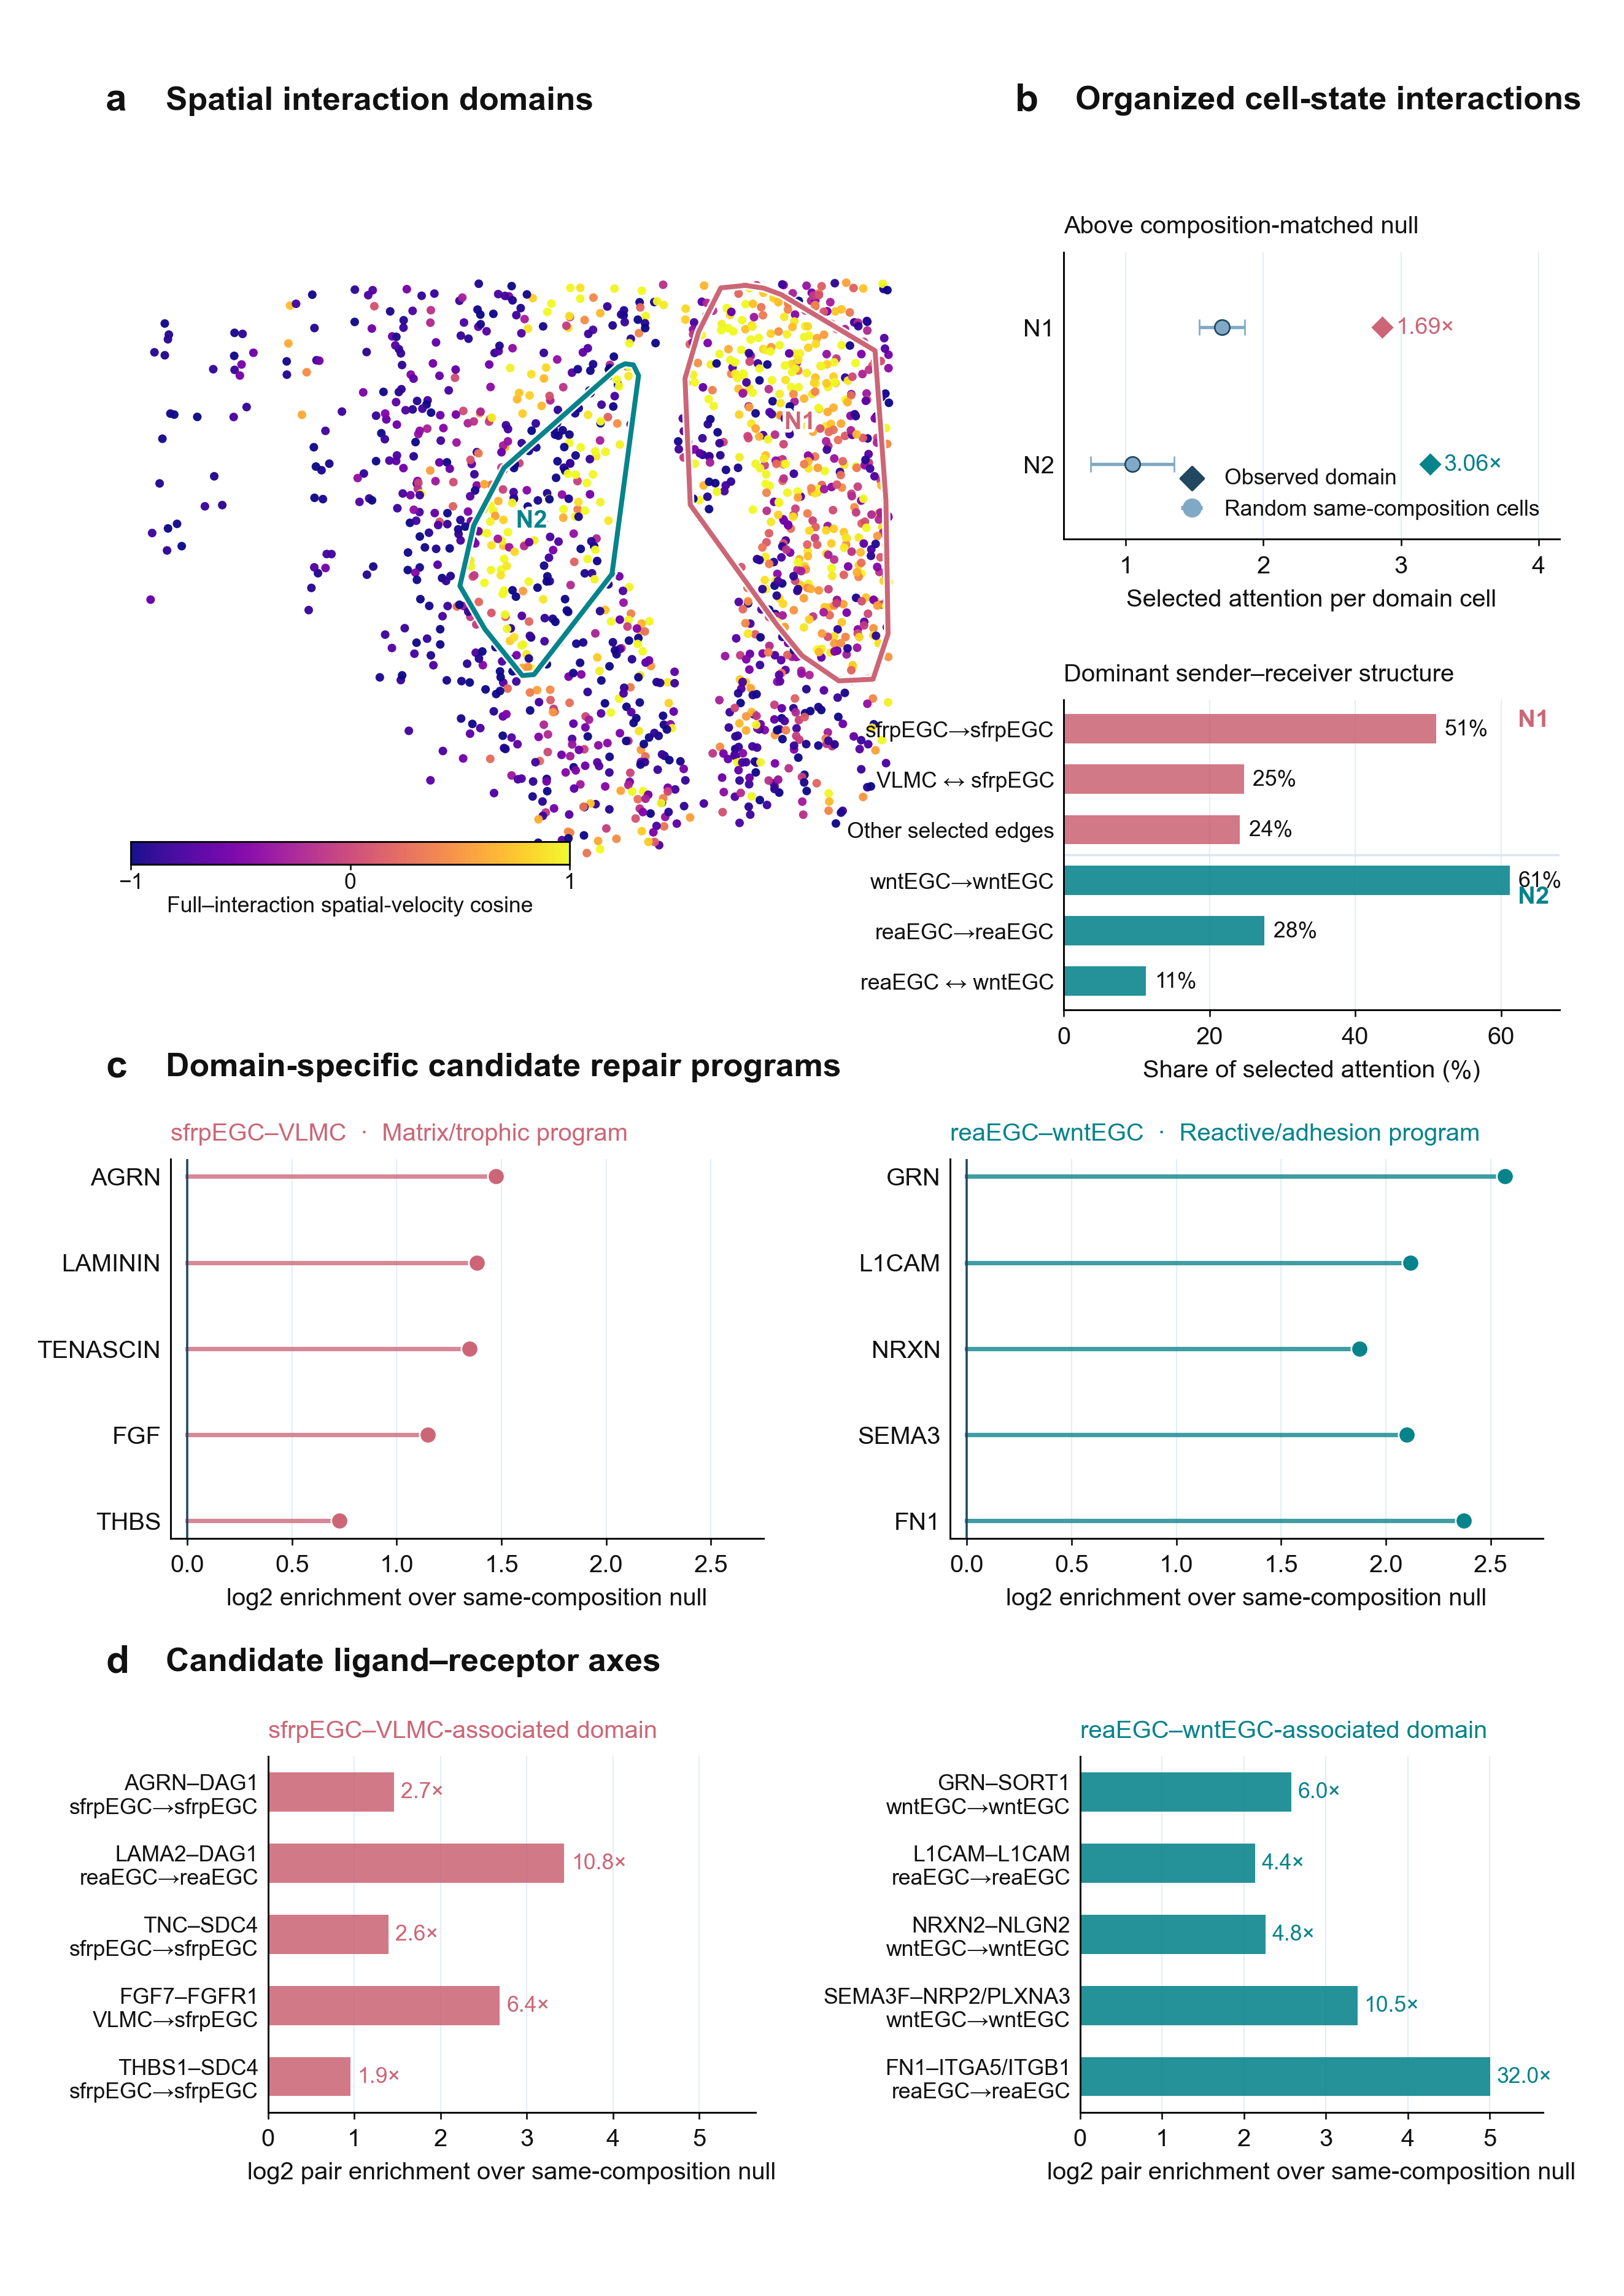

{'tables': {'attention': 'panel_b_attention_matched_null.csv',
  'edge_structure': 'panel_b_selected_edge_structure.csv',
  'pathways': 'panel_c_lr_pathway_enrichment.csv',
  'lr_axes': 'panel_d_candidate_lr_axes.csv'},
 'pdf': 'FigureS_ARISTA_Figure5c_local_interaction_niches_clean.pdf',
 'png': 'FigureS_ARISTA_Figure5c_local_interaction_niches_clean.png'}

In [3]:
table_paths = write_arista_local_domain_tables(panels, output_dir)
pdf_path, png_path = plot_arista_local_domains(data, output_dir, panels)
display(Image(filename=str(png_path), width=700))
{
    "tables": {name: path.name for name, path in table_paths.items()},
    "pdf": pdf_path.name,
    "png": png_path.name,
}
